# Problem Statement

In this project, the goal is to develop a regression model to accurately predict the insurance costs for individual customers based on their demographic and lifestyle attributes. The dataset includes critical factors such as age, BMI, number of children, smoking status, gender, and geographic region, which all contribute to the overall cost of insurance. By building this predictive model, the insurance company can assess risk more accurately, personalize premium pricing, and optimize its pricing strategy, ensuring both competitiveness in the market and profitability. The model will also help identify the key factors that significantly influence insurance costs, enabling targeted customer engagement and risk mitigation strategies.

<center><img src="https://www.canarahsbclife.com/content/dam/choice/blog-inner/images/what-is-insurance-meaning-and-benefits-of-insurance.jpg" width=500/></center>

**Content**  
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.



**Dataset Description:**  
- `age`: Age of the customer (numerical value)

- `sex`: Sex of the customer (Male/Female)

- `bmi`: Bmi ratio of the customer (numberical value)

- `children`: Number of childern (numerical value)

- `smoker`: Is the customer smokes or not (Yes/No)

- `Region`: where did customer located (southeast, southwest, northeast, northwest)
- `expenses`: total medical expenses charged to the individual policyholder


# STEP 1: Import Necessary Libraries & Modules

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import os

# STEP 2: Read Dataset from Google Drive

In [2]:
# Load the data

# Mount the drive
#from google.colab import drive
#drive.mount('/content/drive')




In [51]:
# Read the Excel file, skipping the first row and using the second row as the header

df = pd.read_csv('Insurance.csv')

In [4]:
# View the data
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [6]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


# STEP 3: EDA

Exploratory Data Analysis (EDA) is the process of analyzing and visualizing data to uncover patterns, detect anomalies, test hypotheses, and check assumptions. It helps in understanding the underlying structure of the data before applying modeling techniques.

## 3.1 Check the distribution of `bmi` and list down your observtions


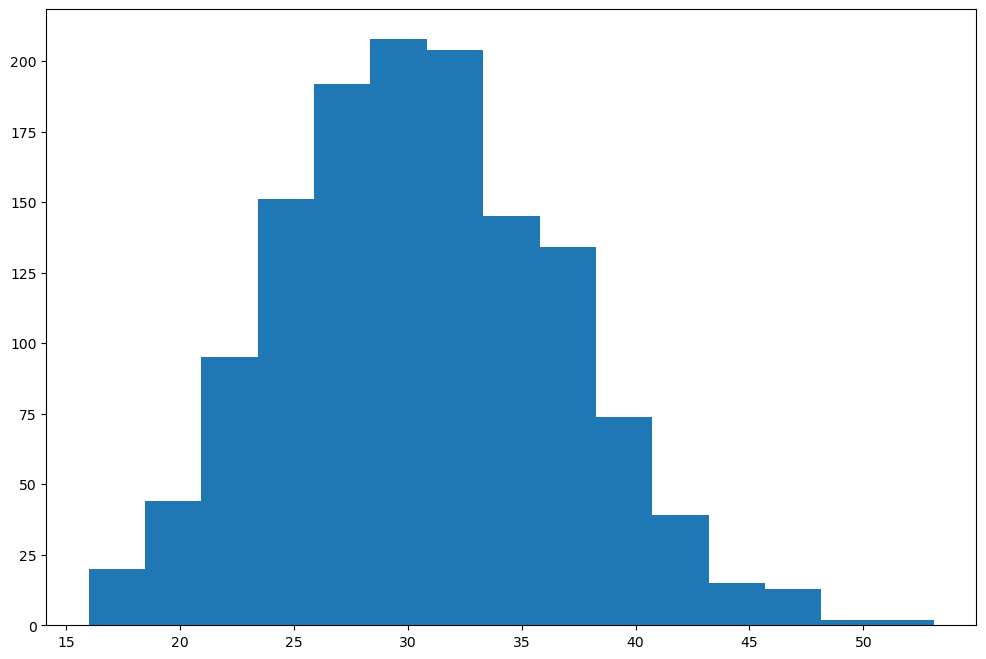

<Axes: xlabel='bmi', ylabel='Count'>

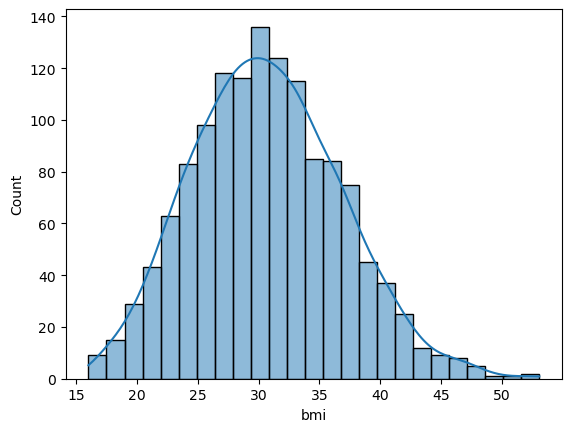

In [11]:
# Create a bmi histogram to see the disribution of bmi
plt.figure(figsize=(12,8))
plt.hist(df['bmi'], bins=15)
plt.show()
# Use histplot from sns library

sns.histplot(df['bmi'], kde=True)


## 3.2 Find the distribution of all the categorical variables and list down your observations.

*Hint: Use pie chart for this visualization*

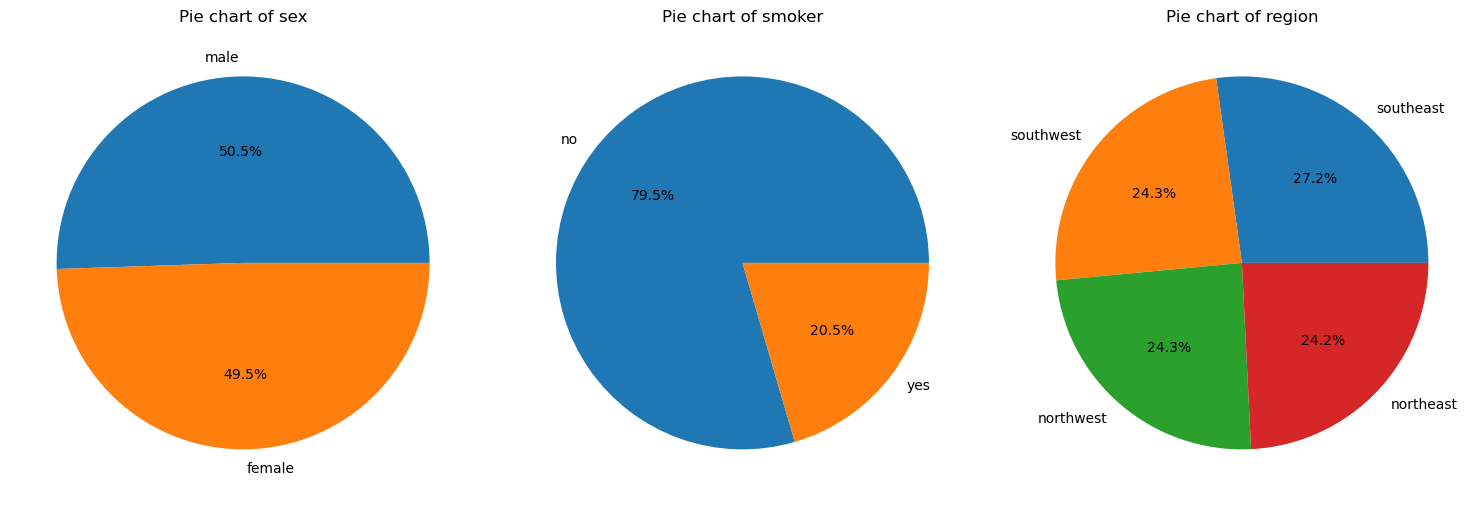

In [19]:
# Visualize the distribution of categorical variables

# Create a list of the categorical columns
categorical_features = [col for col in df.columns if df[col].dtype == 'object']
categorical_features

# Create a subplot with 1 row and 3 columns
fig,axes = plt.subplots(1,3,figsize=(15,5))
# Generate pie charts for the categorical columns
for i, col in enumerate(categorical_features):
    axes[i].set_title(f'Pie chart of {col}')
    axes[i].pie(df[col].value_counts(),
                labels=df[col].value_counts().index,
                autopct='%1.1f%%')

# Adjust the layout to avoid overlap
plt.tight_layout()
plt.show()


## 3.3 Check the relationship between the variables `smoker`, `age`, `expenses`

*Hint: Use scatter plot to find the relationship between the variables.*

<Axes: title={'center': 'Scatter plot to check the relation between smoker, age, and expenses'}, xlabel='age', ylabel='expenses'>

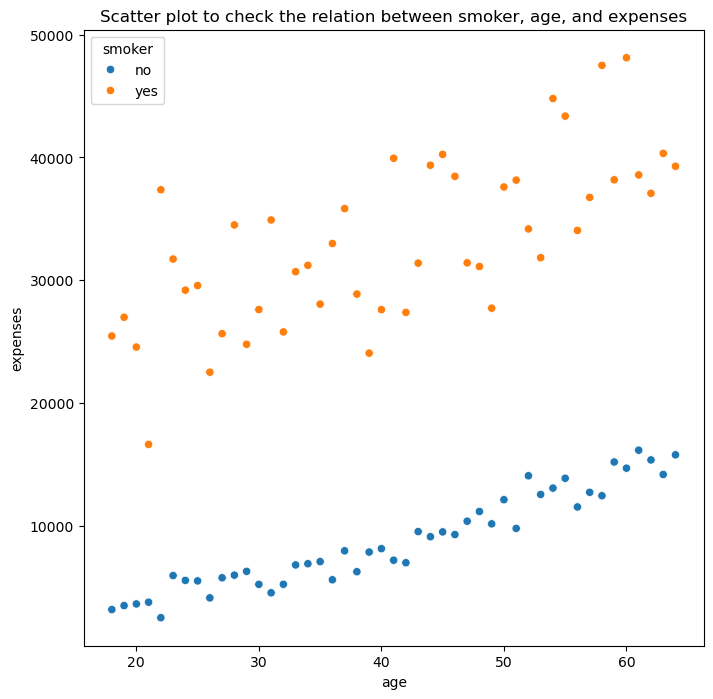

In [27]:
# Checking the relationship between smoker, age, and expenses

# Grouping data by 'smoker' and 'age' to calculate the mean expenses for each group
df_smoker_age = df.groupby(['smoker', 'age'])['expenses'].mean().reset_index()
# Setting up the plot
plt.figure(figsize=(8,8)) 
plt.title('Scatter plot to check the relation between smoker, age, and expenses')

# Creating a scatter plot with 'age' on the x-axis, 'expenses' on the y-axis, and different colors for 'smoker' status
sns.scatterplot(data=df_smoker_age,
                x='age',
                y='expenses',
                hue='smoker')
# Customizing the y-axis ticks to range from 0 to 55,000 with increments of 3,000


# Customizing the x-axis ticks to range from age 17 to 70 with increments of 2 years

# Display the plot



## 3.3 Check the relationship between the variables `smoker`, `bmi`, `expenses`

*Hint: Use scatter plot to find the relationship between the variables.*

<Axes: title={'center': 'Scatter plot to check the relation between smoker, bmi, and expenses'}, xlabel='bmi', ylabel='expenses'>

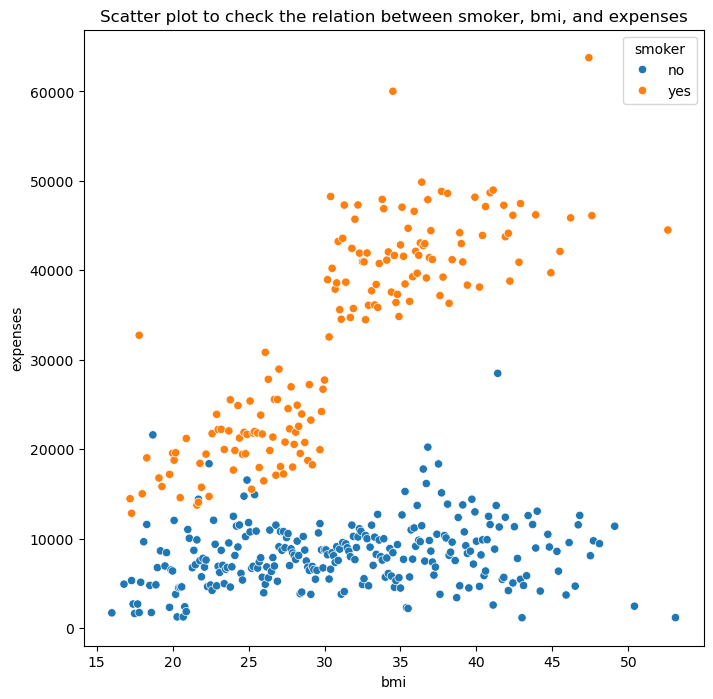

In [30]:
# Checking the relationship between smoker, BMI, and expenses

# Grouping the data by 'smoker' and 'bmi' to calculate the mean expenses for each group
df_smoker_bmi = df.groupby(['smoker', 'bmi'])['expenses'].mean().reset_index()
df_smoker_bmi

# Setting up the plot
plt.figure(figsize=(8,8)) 
plt.title('Scatter plot to check the relation between smoker, bmi, and expenses')

# Creating a scatter plot with 'bmi' on the x-axis, 'expenses' on the y-axis, and different colors for 'smoker' status
sns.scatterplot(data=df_smoker_bmi,
                x='bmi',
                y='expenses',
                hue='smoker')

# Customizing the y-axis ticks to range from 0 to 55,000 with increments of 3,000

# Customizing the x-axis ticks to range from BMI 17 to 70 with increments of 2 units


# Display the plot



## 3.4 Find the outliers (if any) in the numerical variables

*Hint: Use box plot and calculate IQR to detect the outliers.*

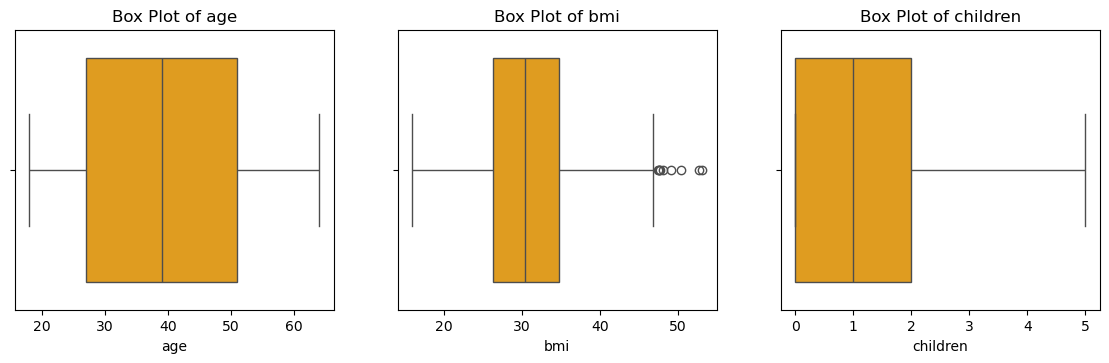


Outliers in age:
Series([], Name: age, dtype: int64)

Outliers in bmi:
116     49.1
286     48.1
401     47.5
543     47.4
847     50.4
860     47.6
1047    52.6
1088    47.7
1317    53.1
Name: bmi, dtype: float64

Outliers in children:
Series([], Name: children, dtype: int64)


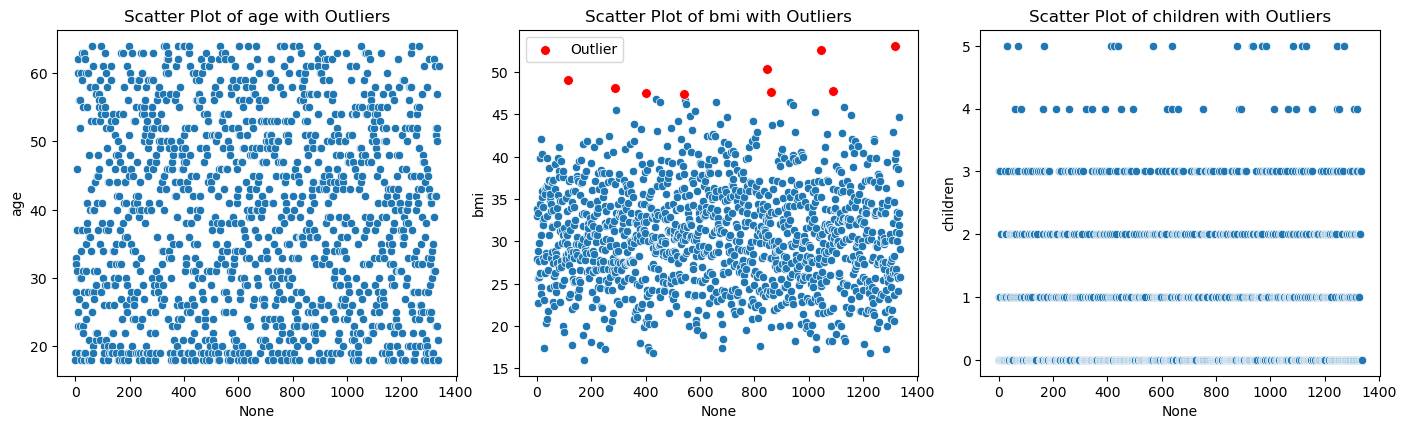

In [43]:
# Identify numerical columns for outlier detection
numerical_features = [ col for col in df.columns if df[col].dtype in  [np.float64, np.int64]]
numerical_features.remove('expenses')

# Visualizing Outliers Using Box Plots
plt.figure(figsize=(14, 8)) 
for i, column in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)  # Create subplots in a 2x3 grid
    sns.boxplot(x=df[column], color='orange')  # Plot a boxplot for each numerical feature
    plt.title(f'Box Plot of {column}')

plt.show()

# Identifying Outliers Using the IQR Method
 # Initialize a dictionary to store outliers
outliers = {}

for column in numerical_features:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile) for the column
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1  # Compute the Interquartile Range (IQR)

    # Define the lower and upper bounds to detect outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers that fall outside the lower and upper bounds
    outliers[column] = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]

    # Print the detected outliers for each numerical feature
    print(f"\nOutliers in {column}:")
    print(outliers[column])

    # Calculate Q1 (25th percentile) and Q3 (75th percentile) for the column
    # Compute the Interquartile Range (IQR)

    # Define the lower and upper bounds to detect outliers


    # Identify outliers that fall outside the lower and upper bounds


    # Print the detected outliers for each numerical feature


# Visualizing Outliers with Scatter Plots
plt.figure(figsize=(14, 8))  # Set up the plot size
for i, column in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)  # Create subplots in a 2x3 grid
    sns.scatterplot(x=df.index, y=df[column])  # Plot the data points
    # Highlight outliers in red with larger markers
    sns.scatterplot(x=outliers[column].index, y=outliers[column], color='red', marker='o', s=50, label='Outlier')
    plt.title(f'Scatter Plot of {column} with Outliers')  # Set the title for each subplot
plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()  # Display the scatter plots with highlighted outliers

# Display the scatter plots with highlighted outliers


## 3.5 Do a complete correlation analysis of the entire data

*Hint: Create dummy variables for all the categorical variables and then use a heatmap to do the correlation analysis.*

['age', 'bmi', 'children']
['sex', 'smoker', 'region']


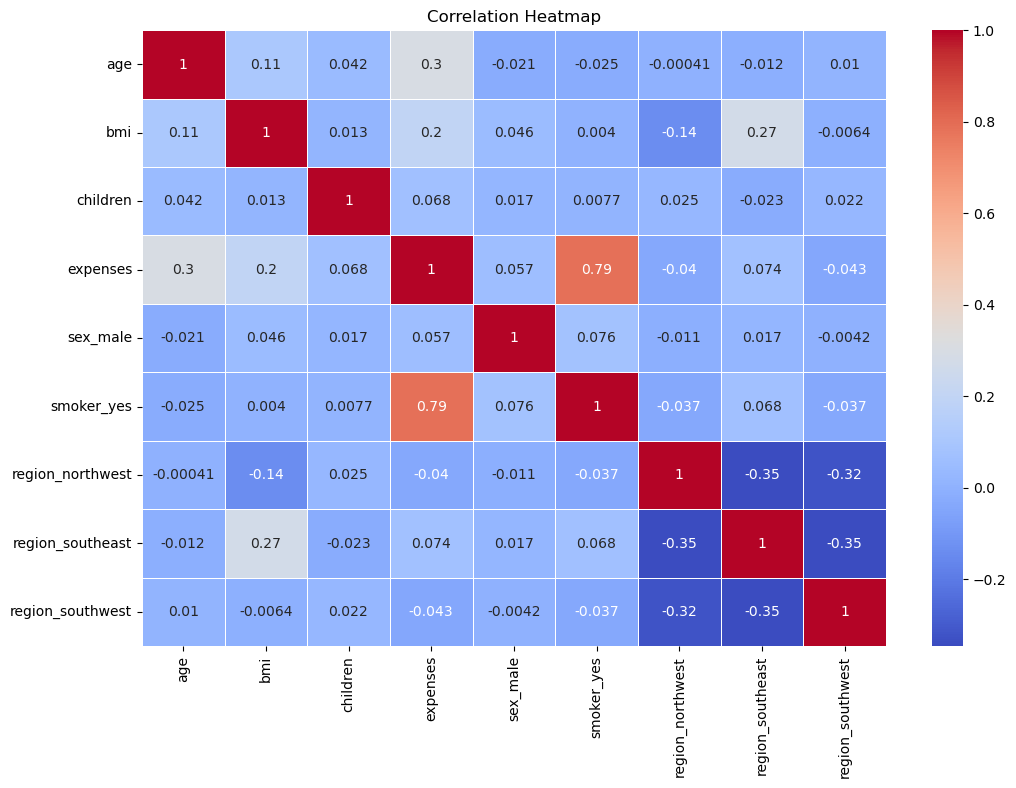

In [52]:
# Identify categorical and numerical columns
print(numerical_features)
print(categorical_features)

# Apply one-hot encoding directly to the entire dataset
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop="first")
encoder.fit(df[categorical_features])
encoded = encoder.transform(df[categorical_features])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_features))

df = df.drop(categorical_features, axis=1).reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

df = pd.concat([df, encoded_df], axis=1)

df.head()




age                 0.299008
bmi                 0.198576
children            0.067998
expenses            1.000000
sex_male            0.057292
smoker_yes          0.787251
region_northwest   -0.039905
region_southeast    0.073982
region_southwest   -0.043210
Name: expenses, dtype: float64


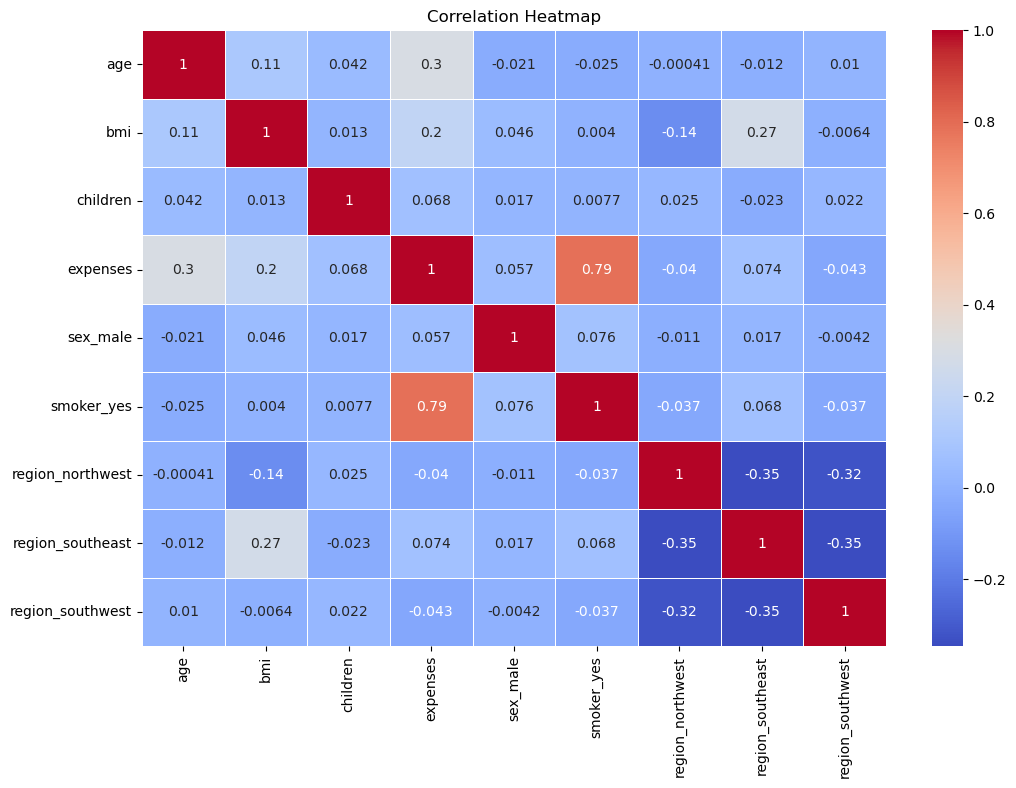

In [54]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Print the correlation with the 'expenses' variable
print(correlation_matrix['expenses'])

# Visualize the correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Correlation Heatmap')
plt.show()

# STEP 4: Data Preprocessing

Data preprocessing is the crucial step of cleaning and transforming raw data into a suitable format for analysis or modeling, ensuring that the data is accurate, complete, and ready for machine learning algorithms. It helps improve model performance and accuracy by addressing issues like missing values, noise, and inconsistencies.

## 4.1 Check for any missing values & handle them if necessary

In [55]:
# Check the dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   bmi               1338 non-null   float64
 2   children          1338 non-null   int64  
 3   expenses          1338 non-null   float64
 4   sex_male          1338 non-null   float64
 5   smoker_yes        1338 non-null   float64
 6   region_northwest  1338 non-null   float64
 7   region_southeast  1338 non-null   float64
 8   region_southwest  1338 non-null   float64
dtypes: float64(7), int64(2)
memory usage: 94.2 KB


# STEP 5: Model Building

## 5.1 Split the data into Training & Test data

*Hint: Use the dummy encoded data.*

In [64]:
# Separate the target & feature variables
features = df.columns.to_list()
features.remove('expenses')

X = df[features]
Y = df['expenses']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Training features:\n", X_train[:5])
print("Training target:\n", y_train[:5])
print("Testing features:\n", X_test[:5])
print("Testing target:\n", y_test[:5])


Training features:
       age   bmi  children  sex_male  smoker_yes  region_northwest  \
560    46  20.0         2       0.0         0.0               1.0   
1285   47  24.3         0       0.0         0.0               0.0   
1142   52  24.9         0       0.0         0.0               0.0   
969    39  34.3         5       0.0         0.0               0.0   
486    54  21.5         3       0.0         0.0               1.0   

      region_southeast  region_southwest  
560                0.0               0.0  
1285               0.0               0.0  
1142               1.0               0.0  
969                1.0               0.0  
486                0.0               0.0  
Training target:
 560      9193.84
1285     8534.67
1142    27117.99
969      8596.83
486     12475.35
Name: expenses, dtype: float64
Testing features:
       age   bmi  children  sex_male  smoker_yes  region_northwest  \
764    45  25.2         2       0.0         0.0               0.0   
887    36  30.0 

## 5.2 Scale the dataset

In [65]:
# Scaling the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # (val - mean_train)/std_train
X_test = scaler.transform(X_test) # (val - mean_train)/std_train
X_train

array([[ 0.47222651, -1.74857248,  0.73433626, ...,  1.78316783,
        -0.59966106, -0.5723141 ],
       [ 0.54331294, -1.03670397, -0.91119211, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [ 0.8987451 , -0.93737348, -0.91119211, ..., -0.56079971,
         1.66760869, -0.5723141 ],
       ...,
       [ 1.3252637 , -0.88770823, -0.91119211, ..., -0.56079971,
        -0.59966106, -0.5723141 ],
       [-0.16755139,  2.82063006,  0.73433626, ..., -0.56079971,
        -0.59966106,  1.74729228],
       [ 1.1120044 , -0.1096194 , -0.91119211, ..., -0.56079971,
        -0.59966106,  1.74729228]], shape=(1070, 8))

## 5.3 Fit the Linear Regression Model

In [66]:
# Initialize the Linear Regression model

# Fit the model to the training data

# Make predictions on the test data
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Fit the model to the training data
lr_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = lr_model.predict(X_test)

y_pred

array([ 8976.76760964,  7061.47078348, 36861.00837958,  9439.16742899,
       26965.82783567, 10866.56613365,   163.68342867, 16902.1625389 ,
        1092.78891435, 11221.84972563, 28100.81510083,  9381.37647426,
        5265.11298425, 38433.51445836, 40248.06655201, 37084.37888675,
       15248.12984097, 35901.53286407,  9127.45708271, 31464.93323459,
        3848.37001706, 10130.91497172,  2370.69195712,  7139.66129952,
       11294.96254187, 12967.62453886, 14509.58195129,  6160.69986604,
        9962.85959031,  2163.07205222,  9116.85372521, 13064.63457975,
        4571.36274084,  3423.94442545,  4460.1164586 , 13031.12862237,
        1979.67910034,  8813.16035987, 33258.81811961, 32584.31750912,
        3910.32992482,  4343.38905053, 14143.48952085, 11435.21647816,
        8791.14158849, 12096.4844327 ,  5272.59144805,  3150.51559564,
       35504.10915377,  9154.13549953, 15835.69309292,  2352.62339682,
       12359.83078765,  1472.69854255, 13377.66583865, 12570.20082856,
      

## 5.4 Check the Coefficients


In [67]:
# Print the best fit regression line
# Print the best fit regression line
print("The best fit line is:",lr_model.coef_[0],"X+",lr_model.intercept_)

The best fit line is: 3614.6976326253093 X+ 13346.089869158879


## 5.5 Evaluate the model - Find MAE, MSE, R-squared

In [68]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")


Linear Regression Model Evaluation:
Mean Absolute Error (MAE): 4181.561524000794
Mean Squared Error (MSE): 33600065.35507784
R-squared (R2): 0.7835726930039905


## 5.6 Calculate Adjusted R-squared value using the formula

Here's the Adjusted R-squared formula formatted for Google Colab markdown:

```
Adjusted R-squared (R²ᴀᴅᴊ) = 1 - [(1 - R²) * (n - 1)] / (n - k - 1)
```

### Where:
- **R²** is the R-squared value of the model.
- **n** is the total number of observations.
- **k** is the number of independent variables (predictors) in the model.



In [69]:
# Calculate the number of observations (n) and the number of predictors (p)
n = X_test.shape[0]
p = X_test.shape[1]
# Calculate the Adjusted R-squared value
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Print the Adjusted R-squared value
print(f'Adjusted R-squared (R²): {adjusted_r2}')



Adjusted R-squared (R²): 0.7768876796604843


## 5.7 Visualize the predictions

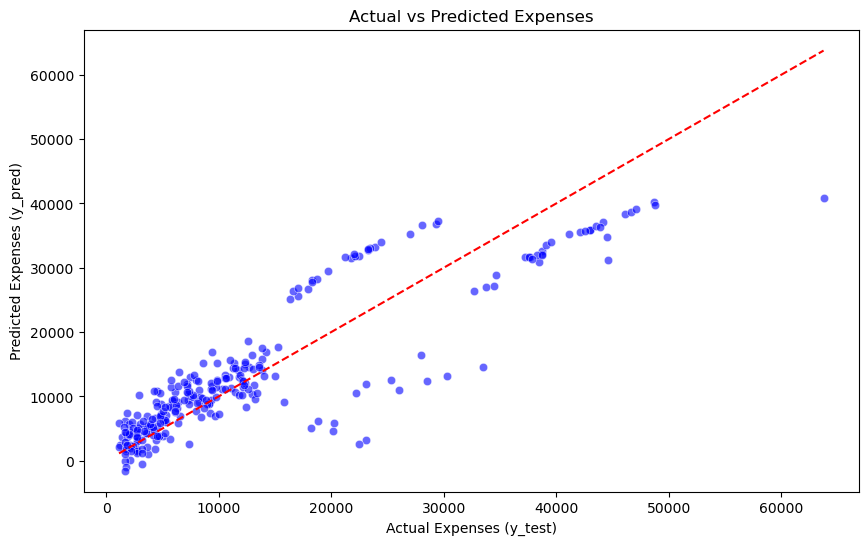

In [70]:
# Visualizing the predictions

plt.figure(figsize=(10, 6))  # Set the figure size for the plot

# Create a scatter plot of actual vs. predicted expenses
sns.scatterplot(x=y_test, y=y_pred, color='blue', alpha=0.6)  # Blue dots represent predicted values vs. actual values

# Add a line plot representing the ideal case where predicted values equal actual values
sns.lineplot(x=y_test, y=y_test, color='red', linestyle='--')  # Red dashed line represents perfect predictions (y_pred = y_test)

# Add titles and labels to the plot
plt.title('Actual vs Predicted Expenses')  # Title of the plot
plt.xlabel('Actual Expenses (y_test)')  # Label for the x-axis
plt.ylabel('Predicted Expenses (y_pred)')  # Label for the y-axis

# Display the plot
plt.show()  # Render the plot
